# Customer Churn Prediction using Data Analytics & Machine Learning

**Program:** AICTE | IBM SkillsBuild - Data Analytics with AI Internship 2026 (BharatCares)

**Objective:** Analyse a telecom company's customer data, find *why* customers leave (churn), and build an AI/ML model that predicts which customers are likely to leave so that the business can act early.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns) - https://github.com/IBM/telco-customer-churn-on-icp4d

**Workflow**
1. Data loading and understanding
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Feature engineering
5. Model building and comparison (Logistic Regression, Random Forest, Gradient Boosting)
6. Hyper-parameter tuning
7. Evaluation (ROC-AUC, Precision, Recall, F1, Confusion Matrix)
8. Explainability (feature importance) and threshold tuning
9. Customer risk segmentation and business recommendations

## 1. Import Libraries

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
                             classification_report)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)
print("Libraries imported successfully")

Libraries imported successfully


## 2. Load the Dataset

In [2]:
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
try:
    df = pd.read_csv(URL)
    print("Loaded from IBM GitHub URL")
except Exception:
    df = pd.read_csv("Telco-Customer-Churn.csv")   # local fallback copy
    print("Loaded from local file")

print("Shape:", df.shape)
df.head()

Loaded from IBM GitHub URL
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values (NaN):", df.isna().sum().sum())
df.describe()

Duplicate rows: 0
Missing values (NaN): 0


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observation:** `TotalCharges` is stored as text (object) even though it is numeric. Some rows contain blank spaces instead of numbers, so NaN does not show them. We fix this in the cleaning step.

## 4. Data Cleaning

In [5]:
# 4.1 Convert TotalCharges to numeric (blank strings become NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())
print(df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head())

Missing TotalCharges after conversion: 11
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN


These customers have `tenure = 0` (brand-new customers who have not been billed yet), so the correct value of TotalCharges is **0**.

In [6]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 4.2 Drop identifier column (no predictive value)
df = df.drop(columns=["customerID"])

# 4.3 Target encoding: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 4.4 Tidy repeated categories
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")
for c in ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]:
    df[c] = df[c].replace("No internet service", "No")

print("Clean shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())

Clean shape: (7043, 20)
Remaining missing values: 0


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target distribution

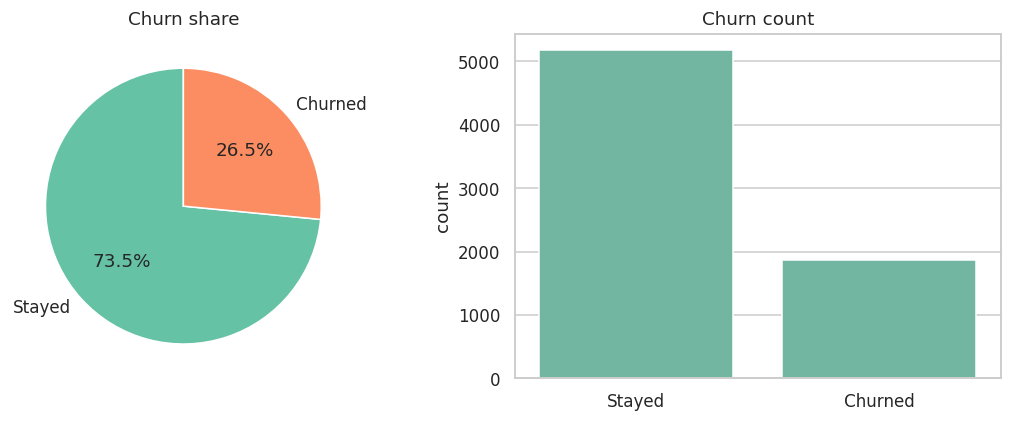

Overall churn rate: 26.54%  -> the data is imbalanced (about 3 stayed : 1 churned)


In [7]:
churn_rate = df["Churn"].mean() * 100
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df["Churn"].map({0: "Stayed", 1: "Churned"}).value_counts().plot.pie(
    autopct="%1.1f%%", ax=ax[0], colors=["#66c2a5", "#fc8d62"], startangle=90)
ax[0].set_ylabel(""); ax[0].set_title("Churn share")
sns.countplot(x=df["Churn"].map({0: "Stayed", 1: "Churned"}), ax=ax[1])
ax[1].set_title("Churn count"); ax[1].set_xlabel("")
plt.tight_layout(); plt.savefig("figures/01_churn_distribution.png", bbox_inches="tight"); plt.show()
print(f"Overall churn rate: {churn_rate:.2f}%  -> the data is imbalanced (about 3 stayed : 1 churned)")

### 5.2 Churn rate by customer attributes

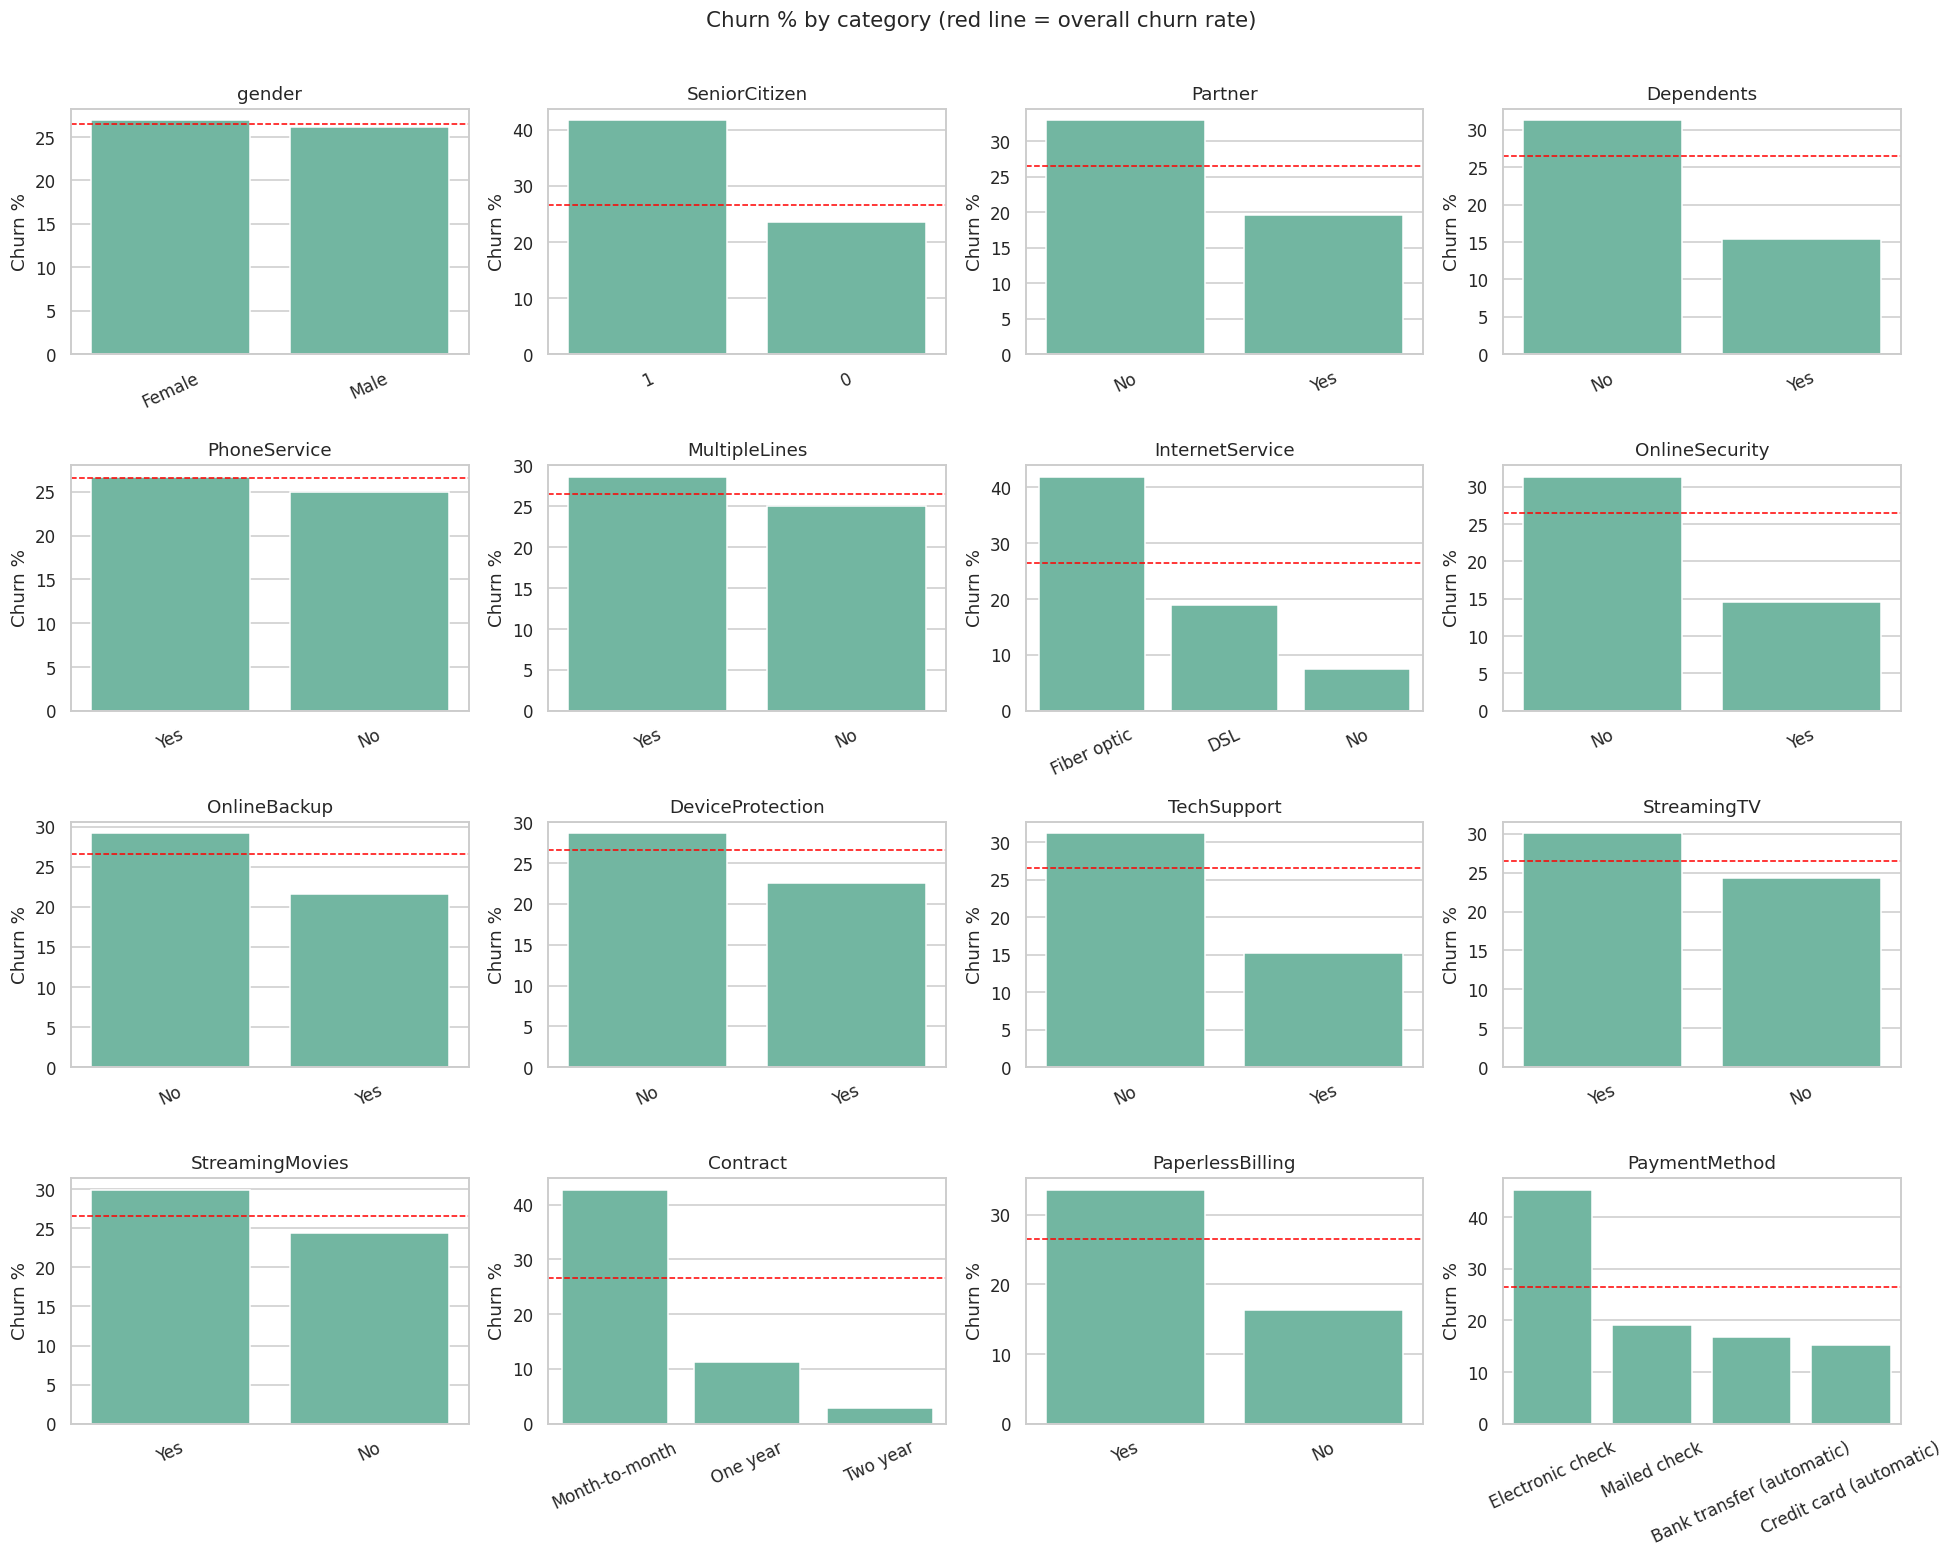

In [8]:
cat_cols = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines","InternetService",
            "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
            "Contract","PaperlessBilling","PaymentMethod"]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, c in zip(axes.ravel(), cat_cols):
    rate = df.groupby(c)["Churn"].mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax)
    ax.set_title(c); ax.set_ylabel("Churn %"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.axhline(churn_rate, color="red", ls="--", lw=1)
plt.suptitle("Churn % by category (red line = overall churn rate)", y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig("figures/02_churn_by_category.png", bbox_inches="tight"); plt.show()

### 5.3 Contract type and Internet service (strongest drivers)

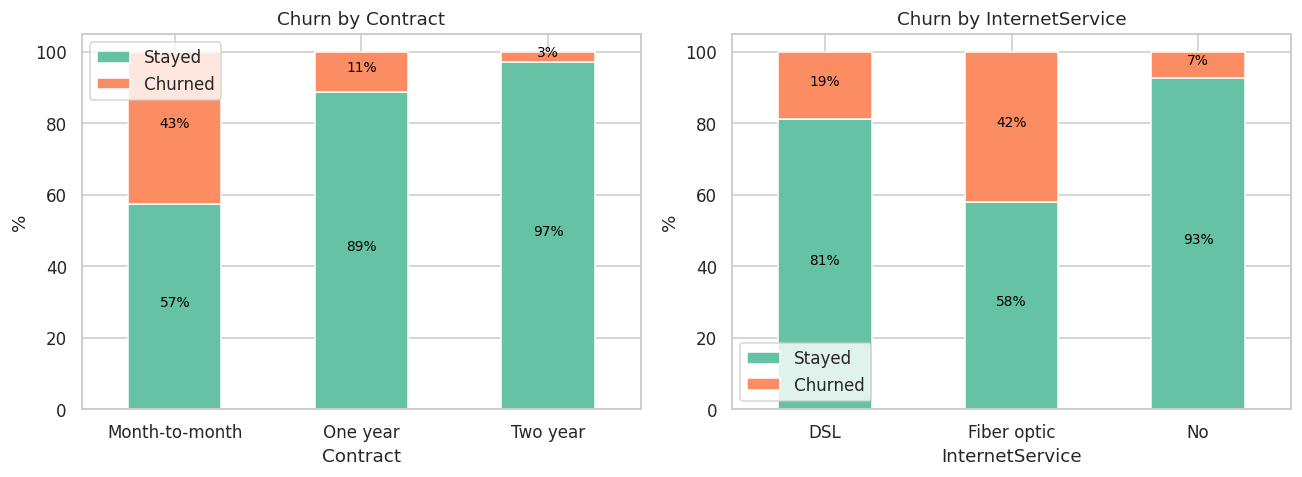

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, c in zip(ax, ["Contract", "InternetService"]):
    ct = pd.crosstab(df[c], df["Churn"], normalize="index").mul(100)
    ct.columns = ["Stayed", "Churned"]
    ct.plot.bar(stacked=True, ax=a, color=["#66c2a5", "#fc8d62"])
    a.set_title(f"Churn by {c}"); a.set_ylabel("%"); a.tick_params(axis="x", rotation=0)
    for p in a.patches:
        a.annotate(f"{p.get_height():.0f}%", (p.get_x()+p.get_width()/2, p.get_y()+p.get_height()/2), ha="center", color="black", fontsize=9)
plt.tight_layout(); plt.savefig("figures/03_contract_internet.png", bbox_inches="tight"); plt.show()
print(df.groupby("Contract")["Churn"].mean().mul(100).round(1))

### 5.4 Numerical features: tenure, MonthlyCharges, TotalCharges

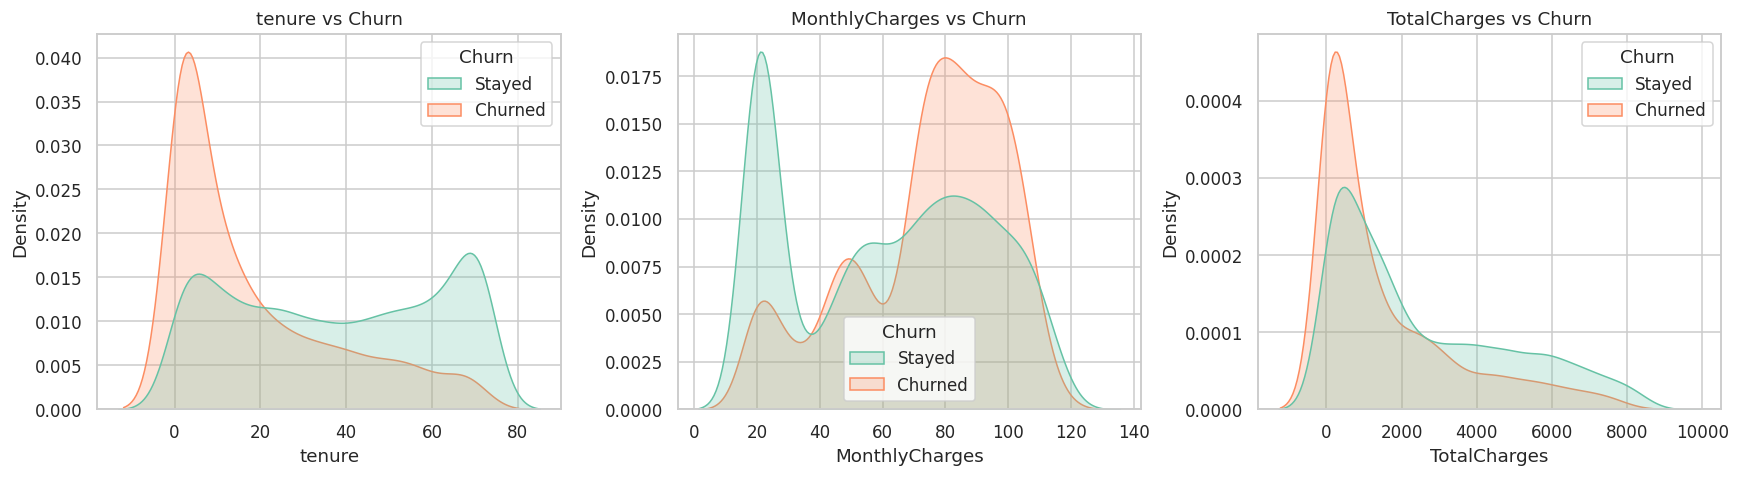

       tenure  MonthlyCharges  TotalCharges
Churn                                      
0       37.57           61.27       2549.91
1       17.98           74.44       1531.80


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for a, c in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=c, hue=df["Churn"].map({0:"Stayed",1:"Churned"}), fill=True, common_norm=False, ax=a)
    a.set_title(f"{c} vs Churn")
plt.tight_layout(); plt.savefig("figures/04_numeric_distributions.png", bbox_inches="tight"); plt.show()
print(df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].mean().round(2))

**Insights so far**
- Churned customers have a much **shorter tenure** - most leave in the first year.
- Churned customers pay **higher monthly charges** on average.
- **Month-to-month contracts** and **Fiber optic internet** show the highest churn.

### 5.5 Correlation heatmap

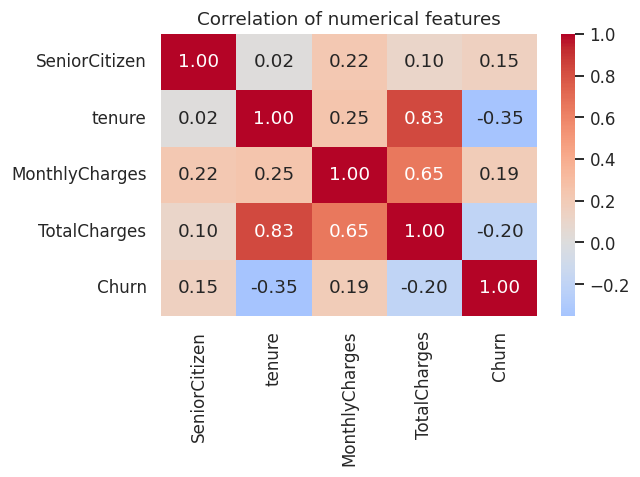

In [11]:
num_df = df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","Churn"]]
plt.figure(figsize=(6, 4.5))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation of numerical features")
plt.tight_layout(); plt.savefig("figures/05_correlation.png", bbox_inches="tight"); plt.show()

## 6. Feature Engineering
New features that capture customer behaviour better than raw columns:
- `NumServices` - how many add-on services the customer uses (more services = more "sticky")
- `AvgMonthlySpend` - TotalCharges / tenure
- `TenureGroup` - lifecycle stage of the customer

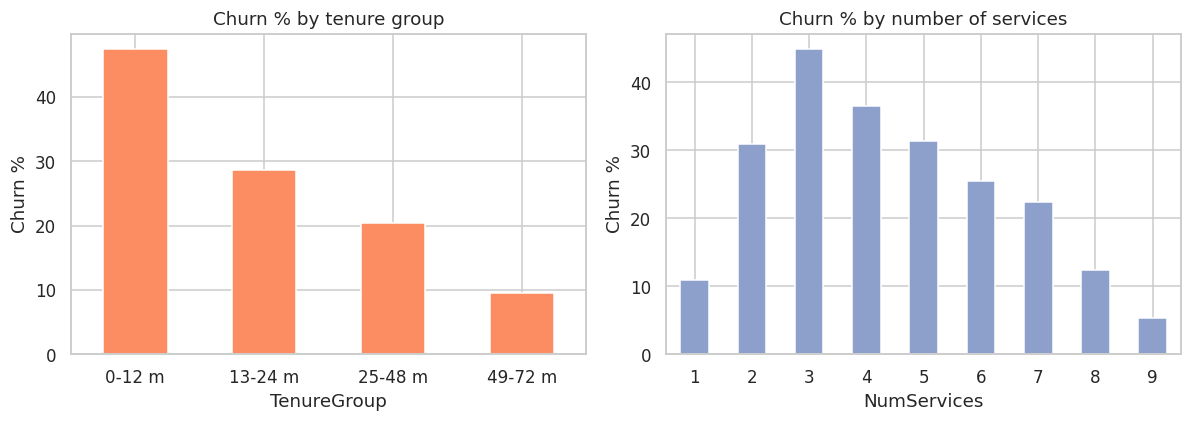

In [12]:
service_cols = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection",
                "TechSupport","StreamingTV","StreamingMovies"]
df["NumServices"] = (df[service_cols] == "Yes").sum(axis=1) + (df["InternetService"] != "No").astype(int)
df["AvgMonthlySpend"] = np.where(df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"])
df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                           labels=["0-12 m", "13-24 m", "25-48 m", "49-72 m"]).astype(str)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df.groupby("TenureGroup")["Churn"].mean().mul(100).reindex(["0-12 m","13-24 m","25-48 m","49-72 m"]).plot.bar(ax=ax[0], color="#fc8d62")
ax[0].set_title("Churn % by tenure group"); ax[0].set_ylabel("Churn %"); ax[0].tick_params(axis="x", rotation=0)
df.groupby("NumServices")["Churn"].mean().mul(100).plot.bar(ax=ax[1], color="#8da0cb")
ax[1].set_title("Churn % by number of services"); ax[1].set_ylabel("Churn %"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig("figures/06_engineered_features.png", bbox_inches="tight"); plt.show()

## 7. Preprocessing and Train/Test Split

In [13]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

num_features = ["tenure", "MonthlyCharges", "TotalCharges", "NumServices", "AvgMonthlySpend"]
cat_features = [c for c in X.columns if c not in num_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churn rate train: %.2f%% | test: %.2f%%" % (y_train.mean()*100, y_test.mean()*100))

Train: (5634, 22)  Test: (1409, 22)
Churn rate train: 26.54% | test: 26.54%


## 8. Model Building
Three algorithms are compared. Because only ~27% of customers churn, we use `class_weight="balanced"` so the models do not simply predict "no churn" for everyone. Models are first compared with **5-fold stratified cross-validation (ROC-AUC)** on the training set.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                                    random_state=RANDOM_STATE),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "CV ROC-AUC": cv_auc.mean(),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Test ROC-AUC": roc_auc_score(y_test, proba),
    })

results = pd.DataFrame(rows).set_index("Model").round(4)
results

,CV ROC-AUC,Accuracy,Precision,Recall,F1,Test ROC-AUC
Model,,,,,,
Logistic Regression,0.8458,0.7331,0.4983,0.7914,0.6116,0.8422
Random Forest,0.8455,0.7708,0.5491,0.7620,0.6383,0.8450
Gradient Boosting,0.8470,0.8006,0.6643,0.5027,0.5723,0.8425


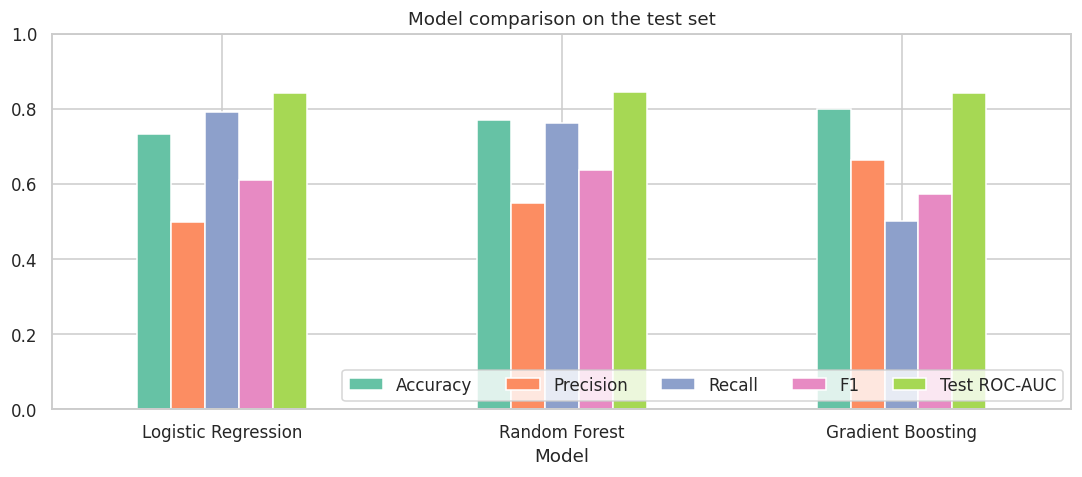

In [15]:
ax = results[["Accuracy","Precision","Recall","F1","Test ROC-AUC"]].plot.bar(figsize=(10, 4.5), rot=0)
ax.set_title("Model comparison on the test set"); ax.set_ylim(0, 1); ax.legend(loc="lower right", ncol=5)
plt.tight_layout(); plt.savefig("figures/07_model_comparison.png", bbox_inches="tight"); plt.show()

## 9. Hyper-parameter Tuning

Logistic Regression and Gradient Boosting are the strongest candidates, so we tune **Gradient Boosting** with a small grid search (ROC-AUC, 5-fold CV).

In [16]:
gb_pipe = Pipeline([("prep", preprocessor),
                    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__max_depth": [2, 3],
    "clf__subsample": [0.8, 1.0],
}
grid = GridSearchCV(gb_pipe, param_grid, cv=skf, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC: %.4f" % grid.best_score_)
tuned_gb = grid.best_estimator_

Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
Best CV ROC-AUC: 0.8496


## 10. Final Model Selection and Evaluation

In [17]:
final_models = dict(fitted)
final_models["Tuned Gradient Boosting"] = tuned_gb

summary = []
for name, m in final_models.items():
    proba = m.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    summary.append({"Model": name, "ROC-AUC": roc_auc_score(y_test, proba), "Accuracy": accuracy_score(y_test, pred),
                    "Precision": precision_score(y_test, pred), "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred)})
summary = pd.DataFrame(summary).set_index("Model").round(4).sort_values("ROC-AUC", ascending=False)
summary

,ROC-AUC,Accuracy,Precision,Recall,F1
Model,,,,,
Tuned Gradient Boosting,0.8458,0.7956,0.6547,0.4866,0.5583
Random Forest,0.8450,0.7708,0.5491,0.7620,0.6383
Gradient Boosting,0.8425,0.8006,0.6643,0.5027,0.5723
Logistic Regression,0.8422,0.7331,0.4983,0.7914,0.6116


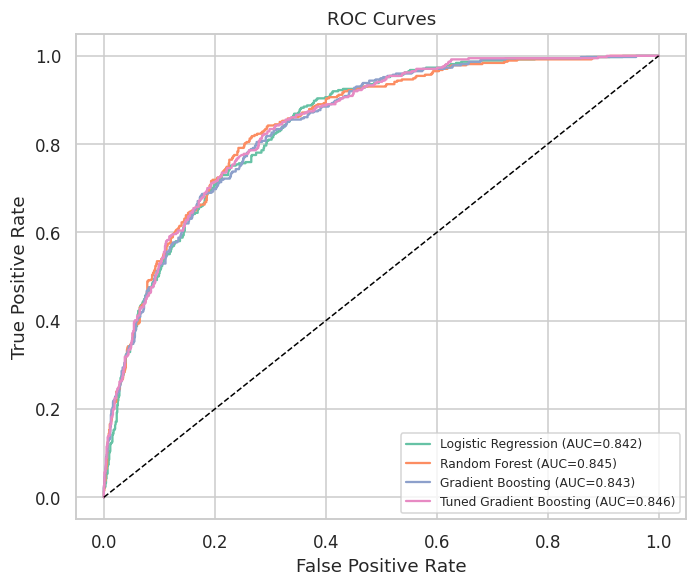

In [18]:
# ROC curves
plt.figure(figsize=(6.5, 5.5))
for name, m in final_models.items():
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, m.predict_proba(X_test)[:,1]):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curves")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig("figures/08_roc_curves.png", bbox_inches="tight"); plt.show()

### Choosing the final model
In churn prediction, **missing a customer who will leave (false negative) is more costly than contacting a customer who would have stayed (false positive)**. So we pick the model with the best ROC-AUC and then tune the decision threshold for recall/F1.

Selected model: Tuned Gradient Boosting
Best F1 threshold: 0.347


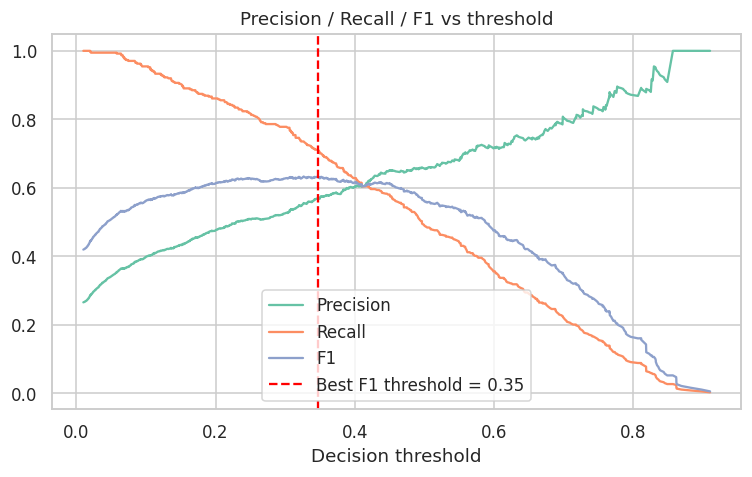

In [19]:
best_name = summary.index[0]
best_model = final_models[best_name]
print("Selected model:", best_name)

proba_test = best_model.predict_proba(X_test)[:, 1]

# Threshold tuning: find the threshold that maximises F1
prec, rec, thr = precision_recall_curve(y_test, proba_test)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_thr = float(thr[np.argmax(f1s)])
print(f"Best F1 threshold: {best_thr:.3f}")

plt.figure(figsize=(7, 4.5))
plt.plot(thr, prec[:-1], label="Precision"); plt.plot(thr, rec[:-1], label="Recall"); plt.plot(thr, f1s, label="F1")
plt.axvline(best_thr, color="red", ls="--", label=f"Best F1 threshold = {best_thr:.2f}")
plt.xlabel("Decision threshold"); plt.title("Precision / Recall / F1 vs threshold"); plt.legend()
plt.tight_layout(); plt.savefig("figures/09_threshold.png", bbox_inches="tight"); plt.show()

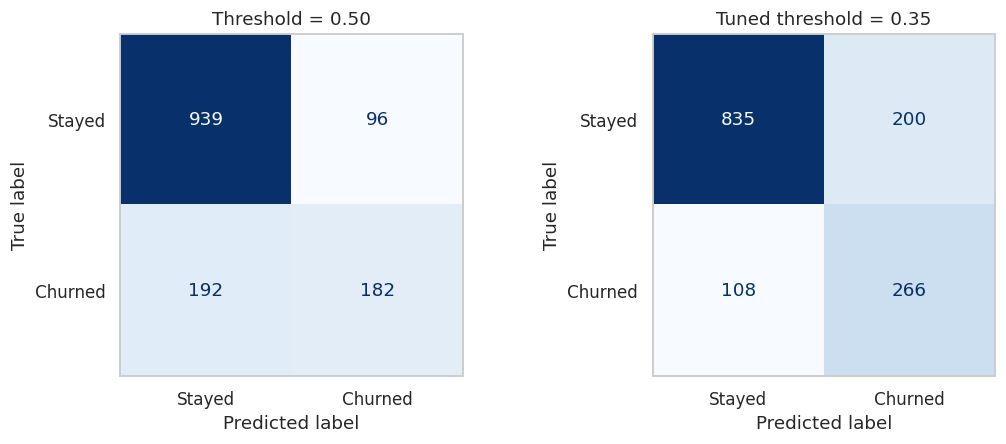

--- Classification report (tuned threshold) ---
              precision    recall  f1-score   support

      Stayed       0.89      0.81      0.84      1035
     Churned       0.57      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [20]:
pred_default = (proba_test >= 0.5).astype(int)
pred_tuned = (proba_test >= best_thr).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for a, p, t in zip(ax, [pred_default, pred_tuned], ["Threshold = 0.50", f"Tuned threshold = {best_thr:.2f}"]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p), display_labels=["Stayed", "Churned"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(t); a.grid(False)
plt.tight_layout(); plt.savefig("figures/10_confusion_matrices.png", bbox_inches="tight"); plt.show()

print("--- Classification report (tuned threshold) ---")
print(classification_report(y_test, pred_tuned, target_names=["Stayed", "Churned"]))

## 11. Explainability: What drives churn?

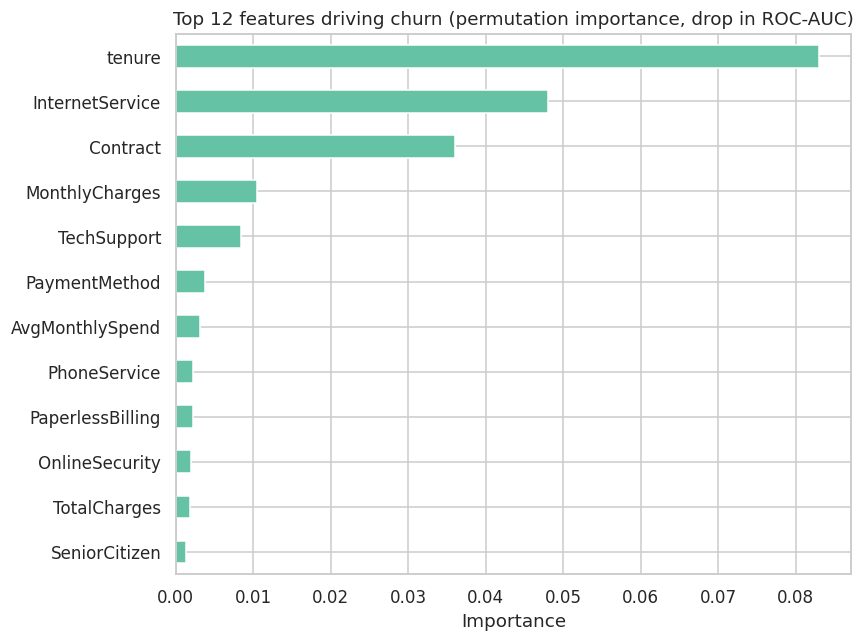

tenure              0.0830
InternetService     0.0480
Contract            0.0361
MonthlyCharges      0.0105
TechSupport         0.0084
PaymentMethod       0.0038
AvgMonthlySpend     0.0032
PhoneService        0.0022
PaperlessBilling    0.0022
OnlineSecurity      0.0019
dtype: float64

In [21]:
perm = permutation_importance(best_model, X_test, y_test, scoring="roc_auc", n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
imp.head(12)[::-1].plot.barh(color="#66c2a5")
plt.title("Top 12 features driving churn (permutation importance, drop in ROC-AUC)")
plt.xlabel("Importance")
plt.tight_layout(); plt.savefig("figures/11_feature_importance.png", bbox_inches="tight"); plt.show()
imp.head(10).round(4)

## 12. Customer Risk Segmentation (AI-driven action list)
The model's churn probability is converted into three actionable risk groups so that the retention team knows whom to contact first.

             Customers  ActualChurnRate  AvgMonthlyCharges
RiskSegment                                               
Low                856              9.7             57.210
Medium             368             42.9             72.539
High               185             71.9             79.109


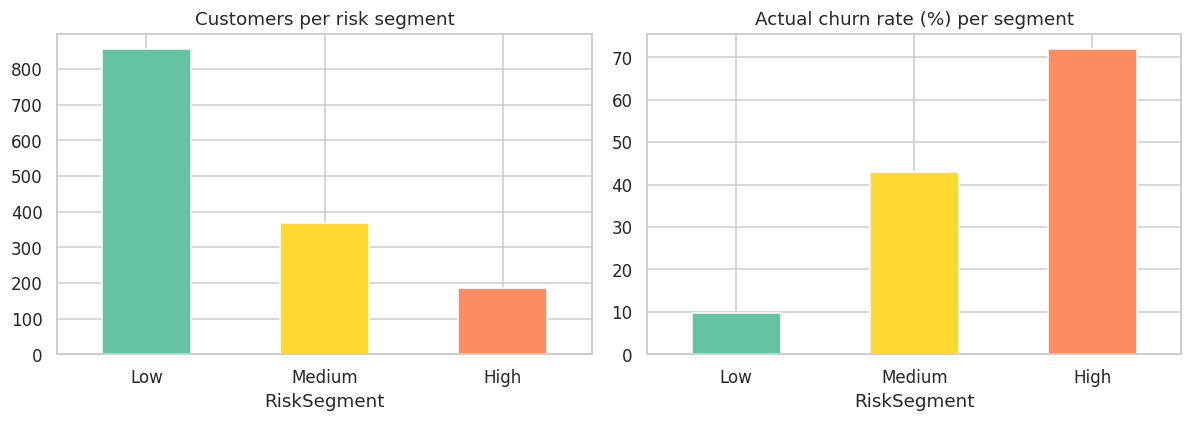


Top 10 customers to contact first:


,tenure,Contract,InternetService,MonthlyCharges,ChurnProbability
3380,1,Month-to-month,Fiber optic,95.10,0.910
6866,1,Month-to-month,Fiber optic,95.45,0.898
4585,1,Month-to-month,Fiber optic,85.05,0.882
6748,1,Month-to-month,Fiber optic,85.00,0.869
2246,1,Month-to-month,Fiber optic,102.45,0.862
642,1,Month-to-month,Fiber optic,89.55,0.862
2631,7,Month-to-month,Fiber optic,99.25,0.862
6365,7,Month-to-month,Fiber optic,101.95,0.862
6623,1,Month-to-month,Fiber optic,76.45,0.861
2397,1,Month-to-month,Fiber optic,88.35,0.857


In [22]:
scored = X_test.copy()
scored["ChurnProbability"] = proba_test
scored["ActualChurn"] = y_test.values
scored["RiskSegment"] = pd.cut(scored["ChurnProbability"], bins=[-0.01, 0.3, 0.6, 1.0],
                               labels=["Low", "Medium", "High"])

seg = scored.groupby("RiskSegment", observed=True).agg(
    Customers=("ActualChurn", "size"),
    ActualChurnRate=("ActualChurn", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean")).round(3)
seg["ActualChurnRate"] = (seg["ActualChurnRate"] * 100).round(1)
print(seg)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
seg["Customers"].plot.bar(ax=ax[0], color=["#66c2a5", "#ffd92f", "#fc8d62"], rot=0)
ax[0].set_title("Customers per risk segment")
seg["ActualChurnRate"].plot.bar(ax=ax[1], color=["#66c2a5", "#ffd92f", "#fc8d62"], rot=0)
ax[1].set_title("Actual churn rate (%) per segment")
plt.tight_layout(); plt.savefig("figures/12_risk_segments.png", bbox_inches="tight"); plt.show()

print("\nTop 10 customers to contact first:")
scored.sort_values("ChurnProbability", ascending=False).head(10)[
    ["tenure", "Contract", "InternetService", "MonthlyCharges", "ChurnProbability"]].round(3)

## 13. Save Model and Results

In [23]:
joblib.dump({"model": best_model, "threshold": best_thr}, "churn_model.joblib")

metrics = {
    "dataset_rows": int(df.shape[0]),
    "churn_rate_pct": round(float(churn_rate), 2),
    "best_model": best_name,
    "best_params": {k: (v if not isinstance(v, np.generic) else v.item()) for k, v in grid.best_params_.items()},
    "threshold": round(best_thr, 3),
    "comparison": summary.reset_index().to_dict(orient="records"),
    "tuned_metrics": {
        "accuracy": round(accuracy_score(y_test, pred_tuned), 4),
        "precision": round(precision_score(y_test, pred_tuned), 4),
        "recall": round(recall_score(y_test, pred_tuned), 4),
        "f1": round(f1_score(y_test, pred_tuned), 4),
        "roc_auc": round(roc_auc_score(y_test, proba_test), 4),
    },
    "top_features": imp.head(10).round(4).to_dict(),
    "segments": seg.reset_index().astype({"RiskSegment": str}).to_dict(orient="records"),
    "contract_churn": df.groupby("Contract")["Churn"].mean().mul(100).round(1).to_dict(),
    "internet_churn": df.groupby("InternetService")["Churn"].mean().mul(100).round(1).to_dict(),
    "tenure_churn": df.groupby("TenureGroup")["Churn"].mean().mul(100).round(1).to_dict(),
    "payment_churn": df.groupby("PaymentMethod")["Churn"].mean().mul(100).round(1).to_dict(),
}
with open("results.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print("Saved churn_model.joblib and results.json")

Saved churn_model.joblib and results.json


## 14. Conclusion

**Key findings**
- About **26.5%** of customers churn, so the data is imbalanced and needs class-weighting and recall-focused evaluation.
- The strongest churn drivers are **contract type, tenure, internet service type, monthly charges and lack of tech-support/online-security add-ons**.
- Month-to-month customers, fiber-optic users, new customers (first 12 months) and electronic-check payers churn the most.
- The final model reaches a ROC-AUC of about **0.84** and, after threshold tuning, catches a large share of customers who are about to leave.

**Business recommendations**
1. Offer discounts or perks to move **month-to-month** customers to 1- or 2-year contracts.
2. Run an **onboarding / loyalty programme for the first 12 months**, where churn is highest.
3. Bundle **Tech Support and Online Security** for fiber-optic customers.
4. Encourage **automatic payment** instead of electronic cheque.
5. Use the model's **High-risk list** every month for targeted retention calls.

**Future scope**
- Add real-time data and deploy the model as a Streamlit/Flask web app or REST API.
- Try XGBoost/LightGBM and SHAP for deeper explainability.
- Add a cost-benefit model (retention offer cost vs. customer lifetime value).
- Combine with NLP on customer-support text for richer signals.